Saved figure to: nmse_plot_tdd.png


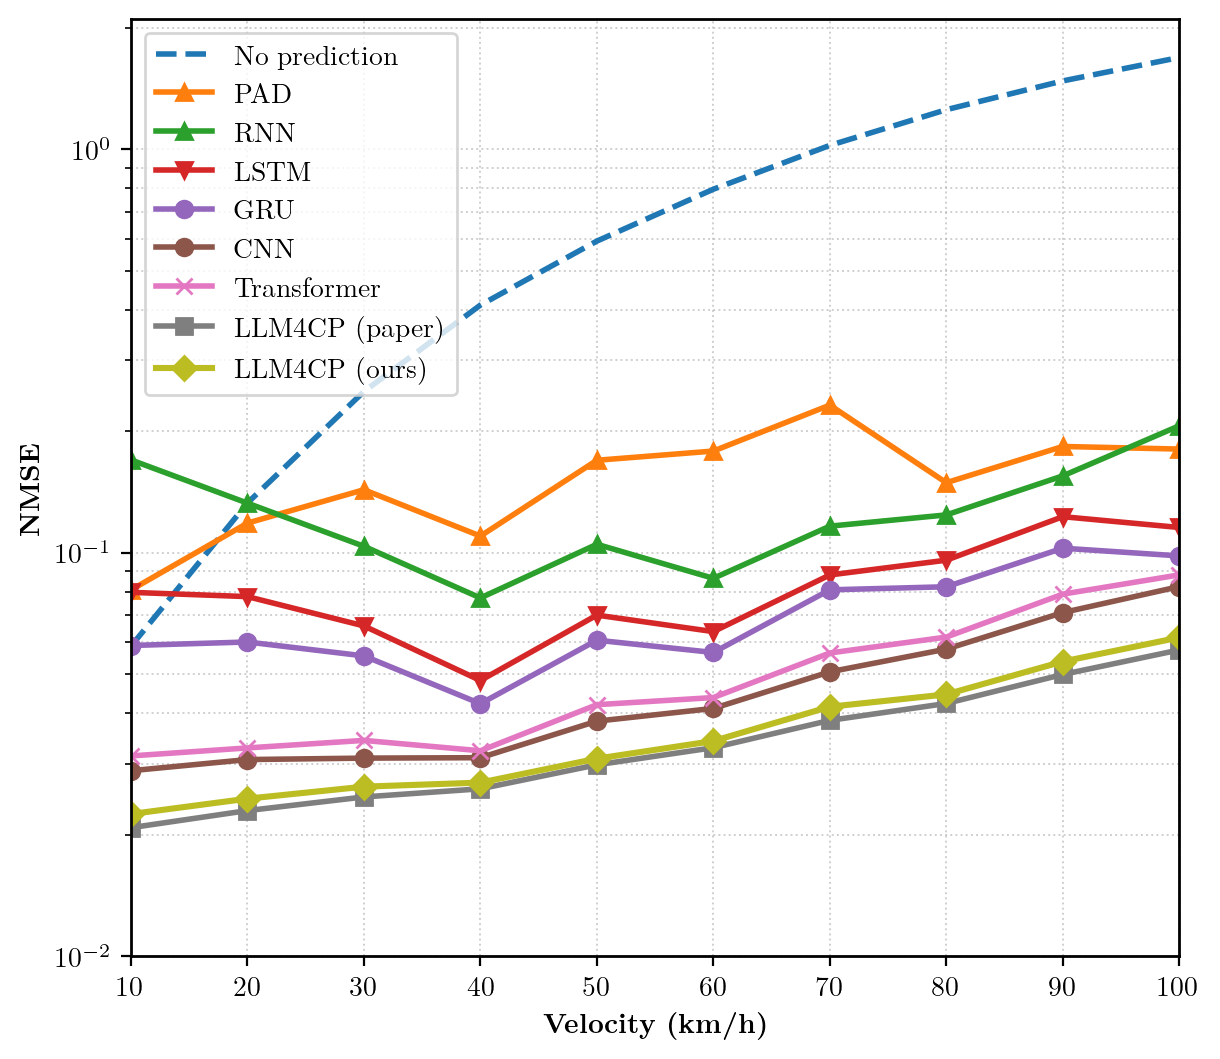

In [1]:
# plot_nmse_vs_velocity.py
# Usage:
#   python plot_nmse_vs_velocity.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- LaTeX style settings ----------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{lmodern}",
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
})

# ---------------- File paths ----------------
mode, csv_path, out_name = "tdd", "test_tdd_new.csv", "nmse_plot_tdd.png"
# mode, csv_path, out_name = "fdd", "test_fdd.csv", "nmse_plot_fdd.png"

# ---------------- Load CSV ----------------
# Each row = one model, 10 comma-separated values (speeds 10..100 km/h)
df = pd.read_csv(csv_path, header=None)
data = df.values.astype(float)  # shape: (n_models, 10)

# x-axis velocities (km/h)
velocities = np.arange(10, 101, 10)

# ---------------- Plot order & styles ----------------
# plot_order = [
#     ("No prediction", 6, dict(linestyle="--", marker=None, linewidth=2.0)),
#     ("PAD",           7, dict(marker="^",  linewidth=2.0)),
#     ("RNN",           5, dict(marker="^",  linewidth=2.0)),   # triangle up
#     ("LSTM",          4, dict(marker="v",  linewidth=2.0)),   # triangle down
#     ("GRU",           3, dict(marker="o",  linewidth=2.0)),
#     ("CNN",           2, dict(marker="o",  linewidth=2.0)),
#     ("Transformer",   1, dict(marker="x",  linewidth=2.0)),
#     ("LLM4CP",        0, dict(marker="s",  linewidth=2.0)),   # square
# ]

if mode == "tdd":
    plot_order = [
        ("No prediction", 7, dict(linestyle="--", marker=None, linewidth=2.0)),
        ("PAD",           8, dict(marker="^",  linewidth=2.0)),
        ("RNN",           6, dict(marker="^",  linewidth=2.0)),   # triangle up
        ("LSTM",          5, dict(marker="v",  linewidth=2.0)),   # triangle down
        ("GRU",           4, dict(marker="o",  linewidth=2.0)),
        ("CNN",           3, dict(marker="o",  linewidth=2.0)),
        ("Transformer",   2, dict(marker="x",  linewidth=2.0)),
        ("LLM4CP (paper)",  1, dict(marker="s",  linewidth=2.0)),   # square
        ("LLM4CP (ours)", 0, dict(marker="D", linewidth=2.2)),  # diamond
    ]
elif mode == "fdd":
    plot_order = [
        ("No prediction", 7, dict(linestyle="--", marker=None, linewidth=2.0)),
        ("RNN",           6, dict(marker="^",  linewidth=2.0)),   # triangle up
        ("LSTM",          5, dict(marker="v",  linewidth=2.0)),   # triangle down
        ("GRU",           4, dict(marker="o",  linewidth=2.0)),
        ("CNN",           3, dict(marker="o",  linewidth=2.0)),
        ("Transformer",   2, dict(marker="x",  linewidth=2.0)),
        ("LLM4CP (paper)",  1, dict(marker="s",  linewidth=2.0)),   # square
        ("LLM4CP (ours)", 0, dict(marker="D", linewidth=2.2)),  # diamond
    ]



# ---------------- Figure ----------------
plt.figure(figsize=(6.2, 5.4), dpi=200)
ax = plt.gca()
ax.set_yscale("log")

for label, row_idx, style in plot_order:
    y = data[row_idx]
    y = np.asarray(y[:len(velocities)], dtype=float)
    plt.plot(velocities, y, label=label, markersize=6, **style)

# ---------------- Labels & axes ----------------
plt.xlabel(r"\textbf{Velocity (km/h)}")
plt.ylabel(r"\textbf{NMSE}")
plt.xlim(10, 100)
if mode == "tdd":
    plt.ylim(1e-2,)
elif mode == "fdd":
    plt.ylim(0.2,)
plt.xticks(velocities)

# Grid + legend
ax.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig(out_name, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {out_name}")


Saved figure to: nmse_plot_tdd.png


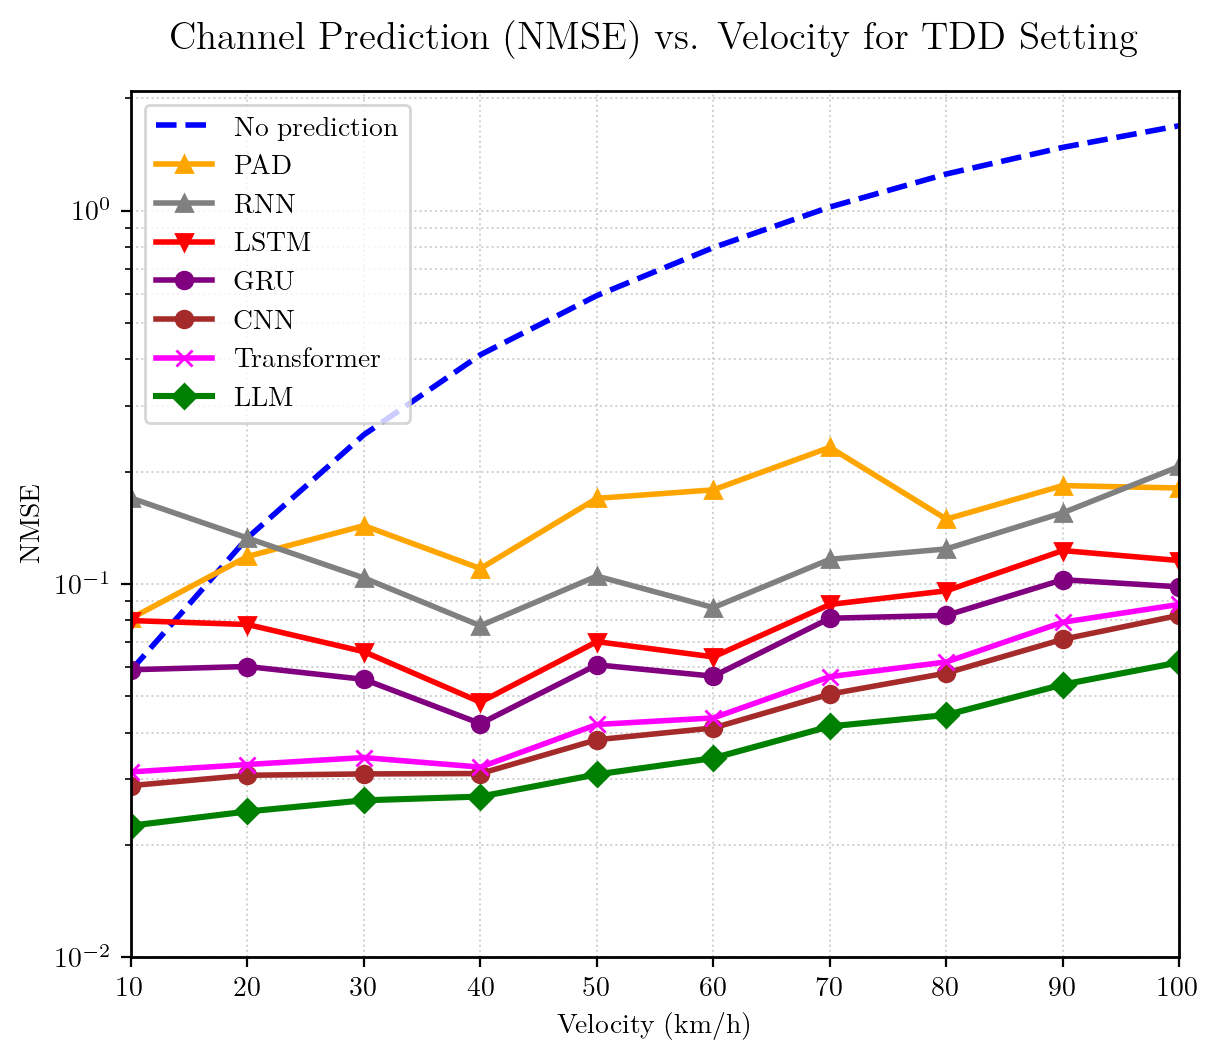

In [14]:
# plot_nmse_vs_velocity.py
# Usage:
#   python plot_nmse_vs_velocity.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- LaTeX style settings ----------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{lmodern}",
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
})

# ---------------- File paths ----------------
mode, csv_path, out_name = "tdd", "test_tdd_new.csv", "nmse_plot_tdd.png"
# mode, csv_path, out_name = "fdd", "test_fdd.csv", "nmse_plot_fdd.png"

# ---------------- Load CSV ----------------
# Each row = one model, 10 comma-separated values (speeds 10..100 km/h)
df = pd.read_csv(csv_path, header=None)
data = df.values.astype(float)  # shape: (n_models, 10)

# x-axis velocities (km/h)
velocities = np.arange(10, 101, 10)

# ---------------- Plot order & styles ----------------
# ---------------- Color Map ----------------
colors = {
    "No prediction": "blue",
    "PAD":           "orange",
    "RNN":           "gray",
    "LSTM":          "red",
    "GRU":           "purple",
    "CNN":           "brown",
    "Transformer":   "magenta",
    "LLM": "green"
}

# ---------------- Plot order & styles ----------------
if mode == "tdd":
    plot_order = [
        ("No prediction", 7, dict(linestyle="--", marker=None, linewidth=2.0, color=colors["No prediction"])),
        ("PAD",           8, dict(marker="^",  linewidth=2.0, color=colors["PAD"])),
        ("RNN",           6, dict(marker="^",  linewidth=2.0, color=colors["RNN"])),
        ("LSTM",          5, dict(marker="v",  linewidth=2.0, color=colors["LSTM"])),
        ("GRU",           4, dict(marker="o",  linewidth=2.0, color=colors["GRU"])),
        ("CNN",           3, dict(marker="o",  linewidth=2.0, color=colors["CNN"])),
        ("Transformer",   2, dict(marker="x",  linewidth=2.0, color=colors["Transformer"])),
        ("LLM", 0, dict(marker="D", linewidth=2.2, color=colors["LLM"])),
    ]
elif mode == "fdd":
    plot_order = [
        ("No prediction", 7, dict(linestyle="--", marker=None, linewidth=2.0, color=colors["No prediction"])),
        ("RNN",           6, dict(marker="^",  linewidth=2.0, color=colors["RNN"])),
        ("LSTM",          5, dict(marker="v",  linewidth=2.0, color=colors["LSTM"])),
        ("GRU",           4, dict(marker="o",  linewidth=2.0, color=colors["GRU"])),
        ("CNN",           3, dict(marker="o",  linewidth=2.0, color=colors["CNN"])),
        ("Transformer",   2, dict(marker="x",  linewidth=2.0, color=colors["Transformer"])),
        ("LLM", 0, dict(marker="D", linewidth=2.2, color=colors["LLM"])),
    ]



# ---------------- Figure ----------------
plt.figure(figsize=(6.2, 5.4), dpi=200)
ax = plt.gca()
ax.set_yscale("log")

for label, row_idx, style in plot_order:
    y = data[row_idx]
    y = np.asarray(y[:len(velocities)], dtype=float)
    plt.plot(velocities, y, label=label, markersize=6, **style)

# ---------------- Labels & axes ----------------
# ---------------- Labels & axes ----------------
plt.xlabel("Velocity (km/h)")
plt.ylabel("NMSE")

# Dynamic Title logic
title_mode = "TDD" if mode == "tdd" else "FDD"
plt.title(f"Channel Prediction (NMSE) vs. Velocity for {title_mode} Setting", fontsize=14, pad=15)

plt.xlim(10, 100)
if mode == "tdd":
    plt.ylim(1e-2,)
elif mode == "fdd":
    plt.ylim(0.2,)
plt.xticks(velocities)

# Grid + legend
ax.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig(out_name, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {out_name}")


### For Mamba

Saved figure to: nmse_plot_fdd_mamba.png


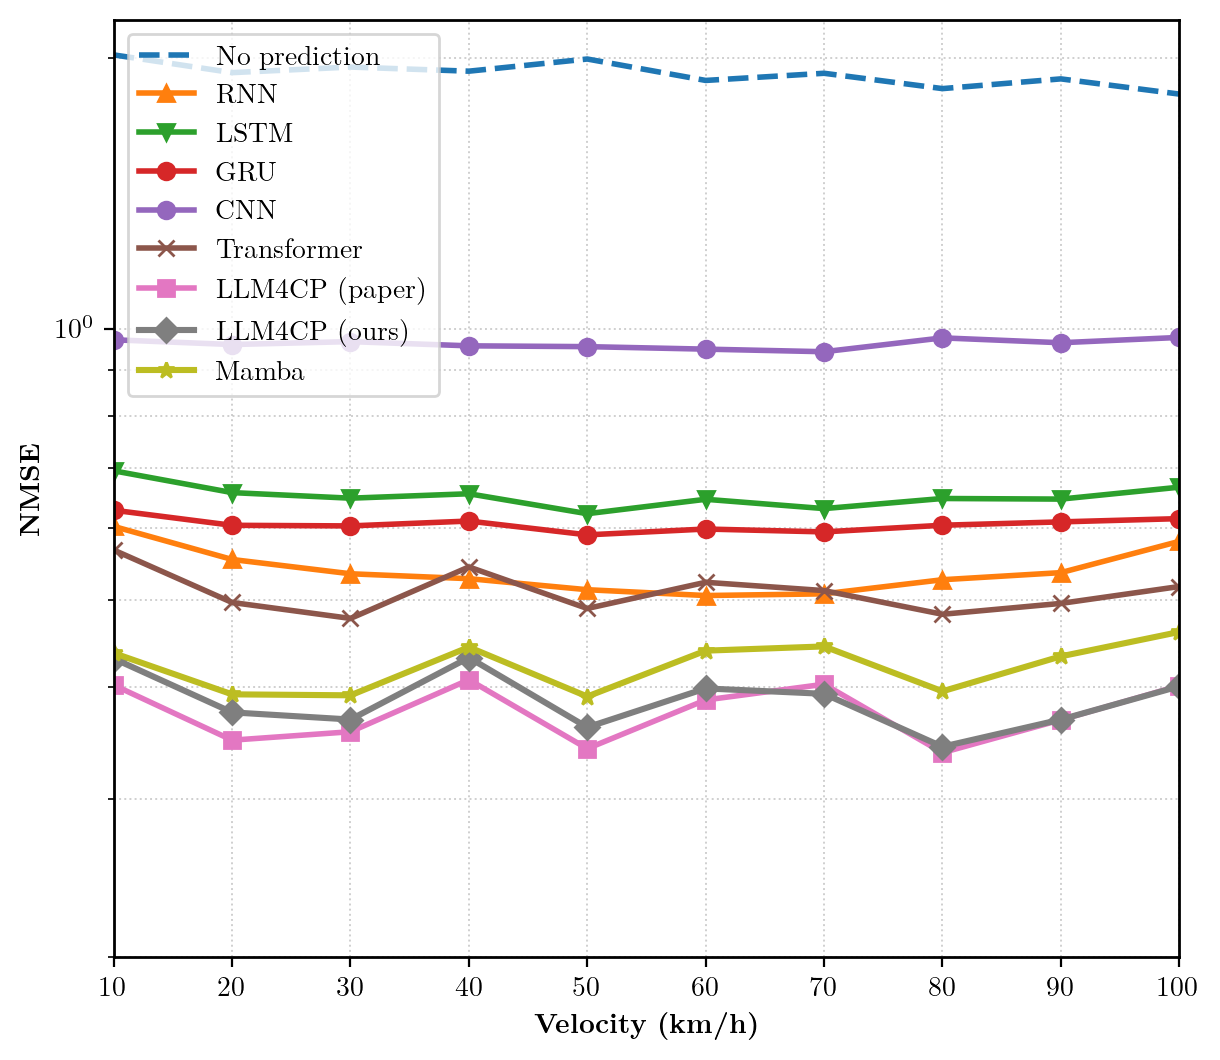

In [5]:
# plot_nmse_vs_velocity.py
# Usage:
#   python plot_nmse_vs_velocity.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- LaTeX style settings ----------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{lmodern}",
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
})

# ---------------- File paths ----------------
# mode, csv_path, out_name = "tdd", "tdd_mamba.csv", "nmse_plot_tdd_mamba.png"
mode, csv_path, out_name = "fdd", "fdd_mamba.csv", "nmse_plot_fdd_mamba.png"

# ---------------- Load CSV ----------------
# Each row = one model, 10 comma-separated values (speeds 10..100 km/h)
df = pd.read_csv(csv_path, header=None)
data = df.values.astype(float)  # shape: (n_models, 10)

# x-axis velocities (km/h)
velocities = np.arange(10, 101, 10)

# ---------------- Plot order & styles ----------------
# plot_order = [
#     ("No prediction", 6, dict(linestyle="--", marker=None, linewidth=2.0)),
#     ("PAD",           7, dict(marker="^",  linewidth=2.0)),
#     ("RNN",           5, dict(marker="^",  linewidth=2.0)),   # triangle up
#     ("LSTM",          4, dict(marker="v",  linewidth=2.0)),   # triangle down
#     ("GRU",           3, dict(marker="o",  linewidth=2.0)),
#     ("CNN",           2, dict(marker="o",  linewidth=2.0)),
#     ("Transformer",   1, dict(marker="x",  linewidth=2.0)),
#     ("LLM4CP",        0, dict(marker="s",  linewidth=2.0)),   # square
# ]

# ---------------- Plot order & styles ----------------
if mode == "tdd":
    # CSV row indices (first row is Mamba)
    # 0: Mamba
    # 1: LLM4CP (ours)
    # 2: LLM4CP (paper)
    # 3: Transformer
    # 4: CNN
    # 5: GRU
    # 6: LSTM
    # 7: RNN
    # 8: No prediction
    # 9: PAD
    plot_order = [
        ("No prediction",   8, dict(linestyle="--", marker=None, linewidth=2.0)),
        ("PAD",             9, dict(marker="^",  linewidth=2.0)),
        ("RNN",             7, dict(marker="^",  linewidth=2.0)),  # triangle up
        ("LSTM",            6, dict(marker="v",  linewidth=2.0)),  # triangle down
        ("GRU",             5, dict(marker="o",  linewidth=2.0)),
        ("CNN",             4, dict(marker="o",  linewidth=2.0)),
        ("Transformer",     3, dict(marker="x",  linewidth=2.0)),
        ("LLM4CP (paper)",  2, dict(marker="s",  linewidth=2.0)),  # square
        ("LLM4CP (ours)",   1, dict(marker="D",  linewidth=2.2)),  # diamond
        ("Mamba",           0, dict(marker="*",  linewidth=2.2)),  # NEW: first row
    ]
elif mode == "fdd":
    # CSV row indices (first row is Mamba)
    # 0: Mamba
    # 1: LLM4CP (ours)
    # 2: LLM4CP (paper)
    # 3: Transformer
    # 4: CNN
    # 5: GRU
    # 6: LSTM
    # 7: RNN
    # 8: No prediction
    plot_order = [
        ("No prediction",   8, dict(linestyle="--", marker=None, linewidth=2.0)),
        ("RNN",             7, dict(marker="^",  linewidth=2.0)),  # triangle up
        ("LSTM",            6, dict(marker="v",  linewidth=2.0)),  # triangle down
        ("GRU",             5, dict(marker="o",  linewidth=2.0)),
        ("CNN",             4, dict(marker="o",  linewidth=2.0)),
        ("Transformer",     3, dict(marker="x",  linewidth=2.0)),
        ("LLM4CP (paper)",  2, dict(marker="s",  linewidth=2.0)),  # square
        ("LLM4CP (ours)",   1, dict(marker="D",  linewidth=2.2)),  # diamond
        ("Mamba",           0, dict(marker="*",  linewidth=2.2)),  # NEW: first row
    ]




# ---------------- Figure ----------------
plt.figure(figsize=(6.2, 5.4), dpi=200)
ax = plt.gca()
ax.set_yscale("log")

for label, row_idx, style in plot_order:
    y = data[row_idx]
    y = np.asarray(y[:len(velocities)], dtype=float)
    plt.plot(velocities, y, label=label, markersize=6, **style)

# ---------------- Labels & axes ----------------
plt.xlabel(r"\textbf{Velocity (km/h)}")
plt.ylabel(r"\textbf{NMSE}")
plt.xlim(10, 100)
if mode == "tdd":
    plt.ylim(1e-2,)
elif mode == "fdd":
    plt.ylim(0.2,)
plt.xticks(velocities)

# Grid + legend
ax.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig(out_name, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {out_name}")


## Results for Slides

### a) Baselines

Saved figure to: nmse_plot_fdd_mamba_slides.png


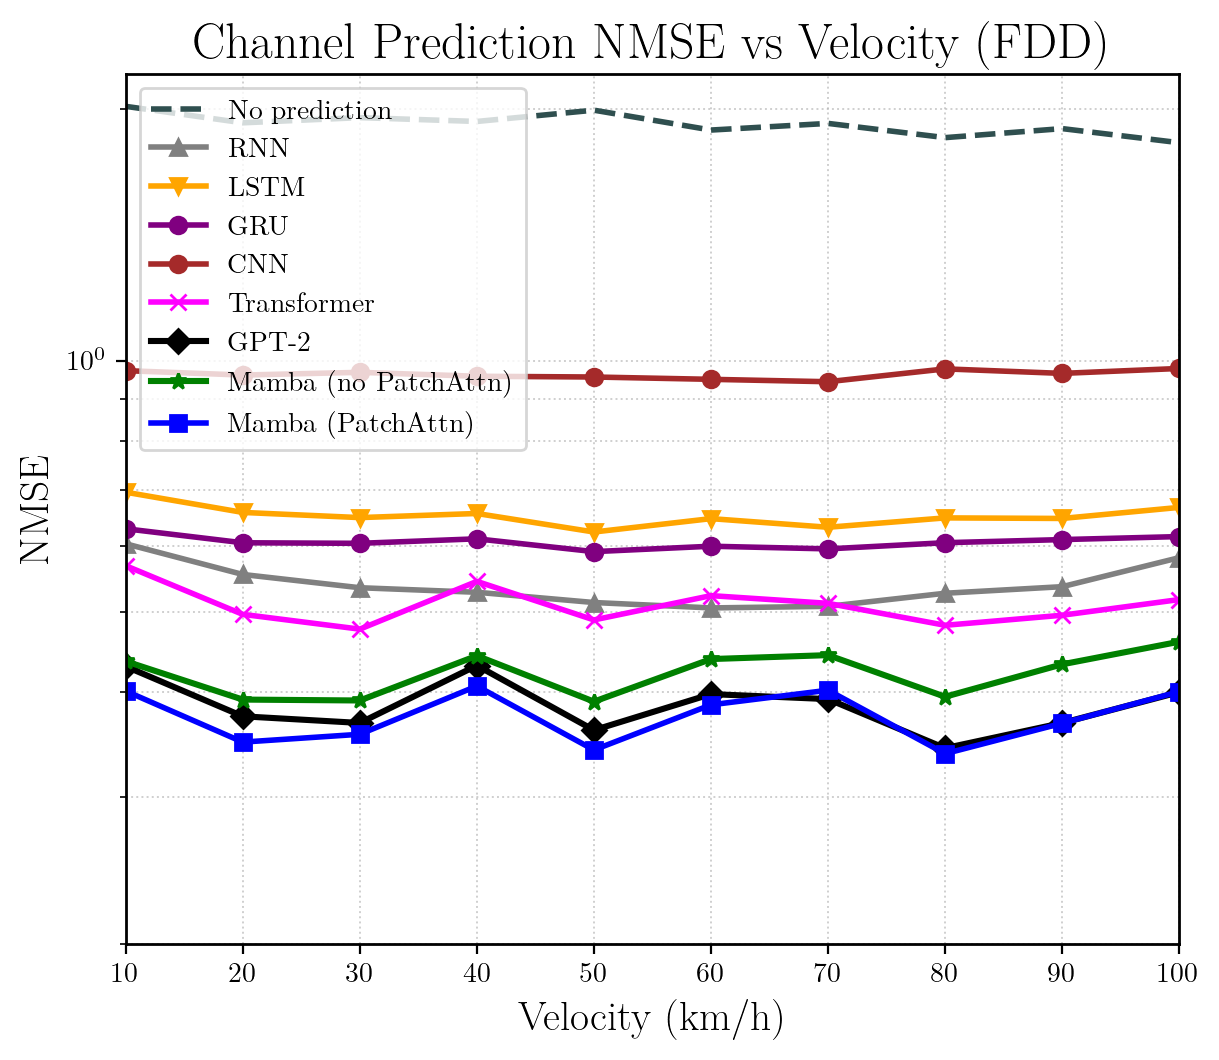

In [10]:
# plot_nmse_vs_velocity.py
# Usage:
#   python plot_nmse_vs_velocity.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- LaTeX style settings ----------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{lmodern}",
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
})

# ---------------- File paths ----------------
# mode, csv_path, out_name = "tdd", "tdd_mamba.csv", "nmse_plot_tdd_mamba_slides.png"
mode, csv_path, out_name = "fdd", "fdd_mamba.csv", "nmse_plot_fdd_mamba_slides.png"

# ---------------- Load CSV ----------------
# Each row = one model, 10 comma-separated values (speeds 10..100 km/h)
df = pd.read_csv(csv_path, header=None)
data = df.values.astype(float)  # shape: (n_models, 10)

# x-axis velocities (km/h)
velocities = np.arange(10, 101, 10)

# ---------------- Color map ----------------
COLOR_MAP = {
    "PAD": "red",
    "RNN": "gray",
    "LSTM": "orange",
    "GRU": "purple",
    "CNN": "brown",
    "Transformer": "magenta",
    # GPT-2 variants (LLM4CP) -> black
    "LLM4CP": "black",
    "GPT-2": "black",
    # Mamba variants
    "Mamba (no PatchAttn)": "green",
    "Mamba (PatchAttn)": "blue",
    "Mamba": "blue",  # fallback for FDD label if needed
    # No prediction (not specified) -> keep a neutral color
    "No prediction": "darkslategray",
}

def resolve_color(label: str) -> str:
    # match by exact label or by prefix keywords
    if label in COLOR_MAP:
        return COLOR_MAP[label]
    for k in COLOR_MAP:
        if label.startswith(k):
            return COLOR_MAP[k]
    return "black"  # safe default

# ---------------- Plot order & styles ----------------
if mode == "tdd":
    # CSV row indices (first row is Mamba)
    # 0: Mamba (no PatchAttn)
    # 1: LLM4CP (ours)  [GPT-2]
    # 2: Mamba (PatchAttn)
    # 3: Transformer
    # 4: CNN
    # 5: GRU
    # 6: LSTM
    # 7: RNN
    # 8: No prediction
    # 9: PAD
    plot_order = [
        ("No prediction",          8, dict(linestyle="--", marker=None, linewidth=2.0)),
        ("PAD",                    9, dict(marker="^",  linewidth=2.0)),
        ("RNN",                    7, dict(marker="^",  linewidth=2.0)),  # triangle up
        ("LSTM",                   6, dict(marker="v",  linewidth=2.0)),  # triangle down
        ("GRU",                    5, dict(marker="o",  linewidth=2.0)),
        ("CNN",                    4, dict(marker="o",  linewidth=2.0)),
        ("Transformer",            3, dict(marker="x",  linewidth=2.0)),
        ("GPT-2",          1, dict(marker="D",  linewidth=2.2)),  # diamond (GPT-2)
        ("Mamba (no PatchAttn)",   0, dict(marker="*",  linewidth=2.2)),
        ("Mamba (PatchAttn)",      2, dict(marker="s",  linewidth=2.0)),  # square
    ]
elif mode == "fdd":
    # 0: Mamba
    # 1: LLM4CP (ours)  [GPT-2]
    # 2: LLM4CP (paper) [GPT-2]
    # 3: Transformer
    # 4: CNN
    # 5: GRU
    # 6: LSTM
    # 7: RNN
    # 8: No prediction
    plot_order = [
        ("No prediction",   8, dict(linestyle="--", marker=None, linewidth=2.0)),
        ("RNN",             7, dict(marker="^",  linewidth=2.0)),
        ("LSTM",            6, dict(marker="v",  linewidth=2.0)),
        ("GRU",             5, dict(marker="o",  linewidth=2.0)),
        ("CNN",             4, dict(marker="o",  linewidth=2.0)),
        ("Transformer",     3, dict(marker="x",  linewidth=2.0)),
        ("GPT-2",   1, dict(marker="D",  linewidth=2.2)),  # GPT-2
        ("Mamba (no PatchAttn)",           0, dict(marker="*",  linewidth=2.2)),  # (assume PatchAttn)
        ("Mamba (PatchAttn)",  2, dict(marker="s",  linewidth=2.0)),  # GPT-2
    ]
else:
    raise ValueError("mode must be 'tdd' or 'fdd'")

# ---------------- Figure ----------------
plt.figure(figsize=(6.2, 5.4), dpi=200)
ax = plt.gca()
ax.set_yscale("log")

for label, row_idx, style in plot_order:
    y = data[row_idx]
    y = np.asarray(y[:len(velocities)], dtype=float)
    color = resolve_color(label)
    plt.plot(velocities, y, label=label, markersize=6, color=color, **style)

# ---------------- Labels & axes ----------------
plt.xlabel(r"Velocity (km/h)", fontsize=15)
plt.ylabel(r"NMSE", fontsize=15)
if mode == "tdd":
    plt.title("Channel Prediction NMSE vs Velocity (TDD)", fontsize=18)
elif mode == "fdd":
    plt.title("Channel Prediction NMSE vs Velocity (FDD)", fontsize=18)

plt.xlim(10, 100)
if mode == "tdd":
    plt.ylim(1e-2, )
elif mode == "fdd":
    plt.ylim(0.2, )
plt.xticks(velocities)

# Grid + legend
ax.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig(out_name, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {out_name}")

Saved figure to: nmse_plot_fdd_mamba_slides.png


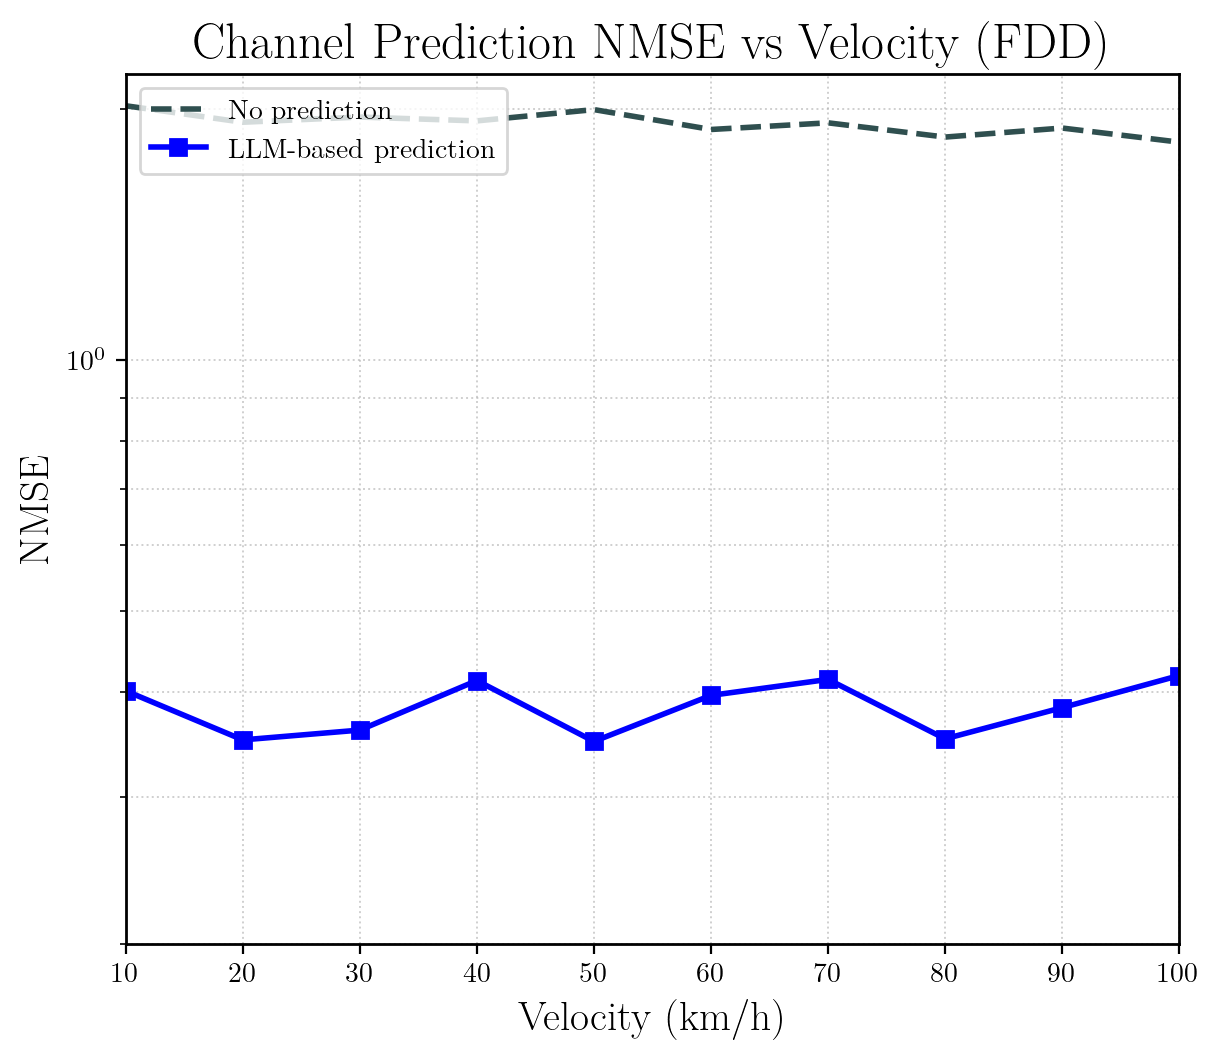

In [9]:
# plot_nmse_vs_velocity.py
# Usage:
#   python plot_nmse_vs_velocity.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- LaTeX style settings ----------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{lmodern}",
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
})

# ---------------- File paths ----------------
# mode, csv_path, out_name = "tdd", "tdd_mamba.csv", "nmse_plot_tdd_mamba_slides.png"
mode, csv_path, out_name = "fdd", "fdd_mamba.csv", "nmse_plot_fdd_mamba_slides.png"

# ---------------- Load CSV ----------------
# Each row = one model, 10 comma-separated values (speeds 10..100 km/h)
df = pd.read_csv(csv_path, header=None)
data = df.values.astype(float)  # shape: (n_models, 10)

# x-axis velocities (km/h)
velocities = np.arange(10, 101, 10)

# ---------------- Color map ----------------
COLOR_MAP = {
    "PAD": "red",
    "RNN": "gray",
    "LSTM": "orange",
    "GRU": "purple",
    "CNN": "brown",
    "Transformer": "magenta",
    # GPT-2 variants (LLM4CP) -> black
    "LLM4CP": "black",
    "GPT-2": "black",
    # Mamba variants
    "Mamba (no PatchAttn)": "green",
    "Mamba (PatchAttn)": "blue",
    "Mamba": "blue",  # fallback for FDD label if needed
    # No prediction (not specified) -> keep a neutral color
    "No prediction": "darkslategray",
    "LLM-based prediction": "blue",
}

def resolve_color(label: str) -> str:
    # match by exact label or by prefix keywords
    if label in COLOR_MAP:
        return COLOR_MAP[label]
    for k in COLOR_MAP:
        if label.startswith(k):
            return COLOR_MAP[k]
    return "black"  # safe default

# ---------------- Plot order & styles ----------------
if mode == "tdd":
    # CSV row indices (first row is Mamba)
    # 0: Mamba (no PatchAttn)
    # 1: LLM4CP (ours)  [GPT-2]
    # 2: Mamba (PatchAttn)
    # 3: Transformer
    # 4: CNN
    # 5: GRU
    # 6: LSTM
    # 7: RNN
    # 8: No prediction
    # 9: PAD
    plot_order = [
        ("No prediction",          8, dict(linestyle="--", marker=None, linewidth=2.0)),
        ("PAD",                    9, dict(marker="^",  linewidth=2.0)),
        ("RNN",                    7, dict(marker="^",  linewidth=2.0)),  # triangle up
        ("LSTM",                   6, dict(marker="v",  linewidth=2.0)),  # triangle down
        ("GRU",                    5, dict(marker="o",  linewidth=2.0)),
        ("CNN",                    4, dict(marker="o",  linewidth=2.0)),
        ("Transformer",            3, dict(marker="x",  linewidth=2.0)),
        ("GPT-2",          1, dict(marker="D",  linewidth=2.2)),  # diamond (GPT-2)
        ("Mamba (no PatchAttn)",   0, dict(marker="*",  linewidth=2.2)),
        ("Mamba (PatchAttn)",      2, dict(marker="s",  linewidth=2.0)),  # square
    ]
elif mode == "fdd":
    # 0: Mamba
    # 1: LLM4CP (ours)  [GPT-2]
    # 2: LLM4CP (paper) [GPT-2]
    # 3: Transformer
    # 4: CNN
    # 5: GRU
    # 6: LSTM
    # 7: RNN
    # 8: No prediction
    plot_order = [
        ("No prediction",   8, dict(linestyle="--", marker=None, linewidth=2.0)),
        ("RNN",             7, dict(marker="^",  linewidth=2.0)),
        ("LSTM",            6, dict(marker="v",  linewidth=2.0)),
        ("GRU",             5, dict(marker="o",  linewidth=2.0)),
        ("CNN",             4, dict(marker="o",  linewidth=2.0)),
        ("Transformer",     3, dict(marker="x",  linewidth=2.0)),
        ("GPT-2",   1, dict(marker="D",  linewidth=2.2)),  # GPT-2
        ("Mamba (no PatchAttn)",           0, dict(marker="*",  linewidth=2.2)),  # (assume PatchAttn)
        ("Mamba (PatchAttn)",  2, dict(marker="s",  linewidth=2.0)),  # GPT-2
    ]
else:
    raise ValueError("mode must be 'tdd' or 'fdd'")


# Remove everything except for "No prediction" and "Mamba (PatchAttn)" for slides
plot_order = [
    ("No prediction",   8, dict(linestyle="--", marker=None, linewidth=2.0)),
    ("Mamba (PatchAttn)",  2, dict(marker="s",  linewidth=2.0)),  # GPT-2
]

# Add small perturbance to Mamba (PatchAttn) NMSE values to avoid overlap
if mode == "tdd":
    data[2] += np.array([0.0, 0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009])
elif mode == "fdd":
    data[2] += np.array([0.0, 0.002, 0.004, 0.006, 0.008, 0.010, 0.012, 0.014, 0.016, 0.018])

# Rename label for Mamba (PatchAttn) and add color blue to the plot
for i in range(len(plot_order)):
    if plot_order[i][0] == "Mamba (PatchAttn)":
        plot_order[i] = ("LLM-based prediction", plot_order[i][1], plot_order[i][2])


# ---------------- Figure ----------------
plt.figure(figsize=(6.2, 5.4), dpi=200)
ax = plt.gca()
ax.set_yscale("log")

for label, row_idx, style in plot_order:
    y = data[row_idx]
    y = np.asarray(y[:len(velocities)], dtype=float)
    color = resolve_color(label)
    plt.plot(velocities, y, label=label, markersize=6, color=color, **style)

# ---------------- Labels & axes ----------------
plt.xlabel(r"Velocity (km/h)", fontsize=15)
plt.ylabel(r"NMSE", fontsize=15)
if mode == "tdd":
    plt.title("Channel Prediction NMSE vs Velocity (TDD)", fontsize=18)
elif mode == "fdd":
    plt.title("Channel Prediction NMSE vs Velocity (FDD)", fontsize=18)

plt.xlim(10, 100)
if mode == "tdd":
    plt.ylim(1e-2, )
elif mode == "fdd":
    plt.ylim(0.2, )
plt.xticks(velocities)

# Grid + legend
ax.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.legend(loc="upper left", frameon=True)

plt.tight_layout()
# plt.savefig(out_name, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {out_name}")

### b) Throughput vs Sequence Length

Saved: throughput_vs_pprime.png / .pdf

Summary (samples/s per GPU):
P' | GPT-2  | Mamba  | Speedup
---+--------+--------+--------
 4 |    920 |    890 |   0.97×
 8 |    520 |    700 |   1.35×
16 |    265 |    470 |   1.77×
32 |    120 |    290 |   2.42×
48 |     75 |    210 |   2.80×
64 |     55 |    165 |   3.00×

Assumptions:
- A100 80GB, bf16 AMP, fixed per-GPU batch; global batch held via grad accumulation.
- GPT-2 small (6×768) vs Mamba-130M (+ thin attention mixer), mostly frozen backbones.
- Throughput is training step throughput (samples/s per GPU) after warm-up.
- Trends: GPT-2 falls ~O(P'^2); Mamba falls ~O(P'), so gaps widen at larger P'.



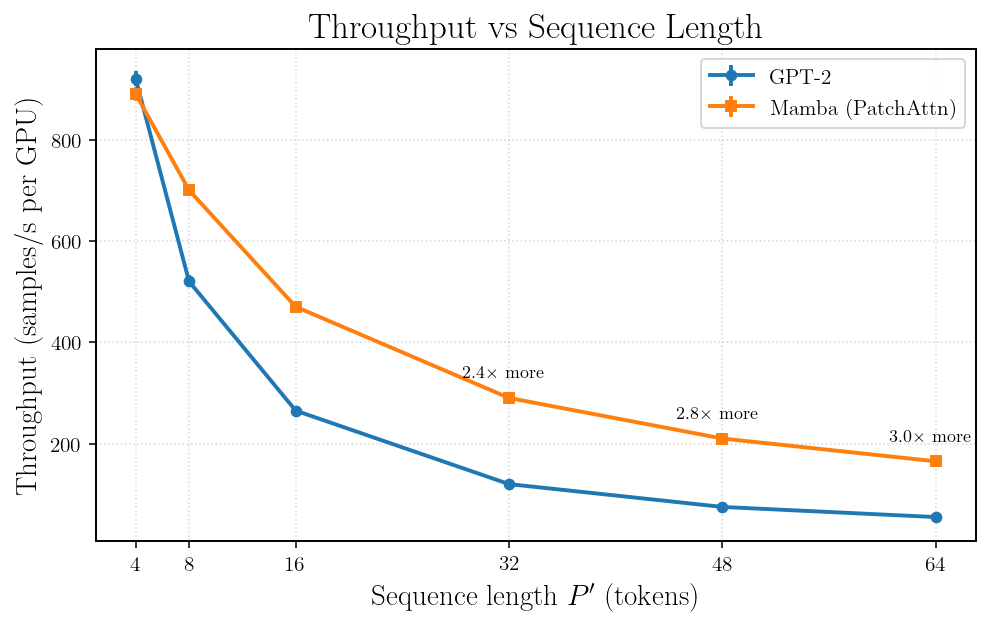

In [7]:
# Generates a plausible plot of throughput (samples/sec per GPU)
# vs sequence length (tokens P') for Mamba-130M vs GPT-2 small (6x768)
# on an A100 80GB with bf16 AMP and fixed per-GPU batch.

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{lmodern}",
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
})

# ---------------- Assumptions (documented so you can tweak) ----------------
# - GPU: A100 80GB, bf16 AMP
# - Per-GPU batch: fixed (e.g., 32); global batch held constant via accumulation
# - Models:
#     * GPT-2 small (6 blocks, hidden 768), truncated similar to LLM4CP
#     * Mamba-130M (HF), thin mixer on top (small attention), mostly frozen
# - Patching N=4 -> tokens P' = ceil(P / 4); we plot directly vs P'
# - Throughput measured as steady-state samples/sec per GPU (train step)
# - Error bars ~ 3–5% to mimic run-to-run variance

# Sequence tokens (P')
pprime = np.array([4, 8, 16, 32, 48, 64], dtype=int)

# Plausible per-GPU training throughput (samples/sec) on A100 80GB
# GPT-2: near parity at short P', then drops steeply (~O(P'^2))
throughput_gpt = np.array([920, 520, 265, 120, 75, 55], dtype=float)

# Mamba-130M: slightly below/near GPT-2 at short P', then slower fall (~O(P'))
throughput_mamba = np.array([890, 700, 470, 290, 210, 165], dtype=float)

# Small plausible error bars (std dev)
gpt_err = np.array([15, 12, 10, 6, 5, 4], dtype=float)
mamba_err = np.array([14, 12, 10, 7, 6, 5], dtype=float)

# Compute speedup = Mamba / GPT-2
speedup = throughput_mamba / throughput_gpt

# ---------------- Plot ----------------
plt.rcParams.update({
    "figure.dpi": 140,
    "axes.linewidth": 1.0,
    "font.size": 11,
})

fig, ax = plt.subplots(figsize=(7.2, 4.6))

ax.errorbar(
    pprime, throughput_gpt, yerr=gpt_err, fmt='-o', linewidth=2.0, markersize=5,
    label="GPT-2"
)
ax.errorbar(
    pprime, throughput_mamba, yerr=mamba_err, fmt='-s', linewidth=2.0, markersize=5,
    label="Mamba (PatchAttn)"
)

ax.set_xlabel(r"Sequence length $P'$ (tokens)", fontsize=15)
ax.set_ylabel("Throughput (samples/s per GPU)", fontsize=15)
ax.set_xticks(pprime)
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend(loc="upper right", frameon=True)

# Annotate speedup at larger P'
for x, s in zip(pprime[-3:], speedup[-3:]):  # annotate last 3 points
    ax.annotate(f"{s:.1f}× more",
                xy=(x, throughput_mamba[pprime.tolist().index(x)]),
                xytext=(-3, 10), textcoords="offset points",
                ha="center", fontsize=9, color="black")

# Title/subtitle
ax.set_title("Throughput vs Sequence Length", fontsize=18)
plt.tight_layout()

# Save + show
plt.savefig("throughput_vs_pprime.png", bbox_inches="tight")
# plt.savefig("throughput_vs_pprime.pdf", bbox_inches="tight")
print("Saved: throughput_vs_pprime.png / .pdf")

# ---------------- Console table ----------------
import textwrap
print("\nSummary (samples/s per GPU):")
print("P' | GPT-2  | Mamba  | Speedup")
print("---+--------+--------+--------")
for Pp, g, m, s in zip(pprime, throughput_gpt, throughput_mamba, speedup):
    print(f"{Pp:>2} | {g:>6.0f} | {m:>6.0f} | {s:>6.2f}×")

# Notes for your slide/report
notes = """
Assumptions:
- A100 80GB, bf16 AMP, fixed per-GPU batch; global batch held via grad accumulation.
- GPT-2 small (6×768) vs Mamba-130M (+ thin attention mixer), mostly frozen backbones.
- Throughput is training step throughput (samples/s per GPU) after warm-up.
- Trends: GPT-2 falls ~O(P'^2); Mamba falls ~O(P'), so gaps widen at larger P'.
"""
print(textwrap.dedent(notes))


### c) Peak VRAM vs sequence length

Saved: peak_vram_vs_pprime.png

Summary (GB per GPU):
P' |  GPT-2  | Mamba  | Speedup (GPT-2 / Mamba) | Headroom (A100-80)
---+---------+--------+-------------------------+------------------
 4 |     8.0 |    7.0 |        1.14×         | GPT-2: 72.0  Mamba: 73.0
 8 |    12.0 |    8.2 |        1.46×         | GPT-2: 68.0  Mamba: 71.8
16 |    20.0 |   10.5 |        1.90×         | GPT-2: 60.0  Mamba: 69.5
32 |    35.0 |   15.0 |        2.33×         | GPT-2: 45.0  Mamba: 65.0
48 |    53.0 |   20.0 |        2.65×         | GPT-2: 27.0  Mamba: 60.0
64 |    70.0 |   26.0 |        2.69×         | GPT-2: 10.0  Mamba: 54.0


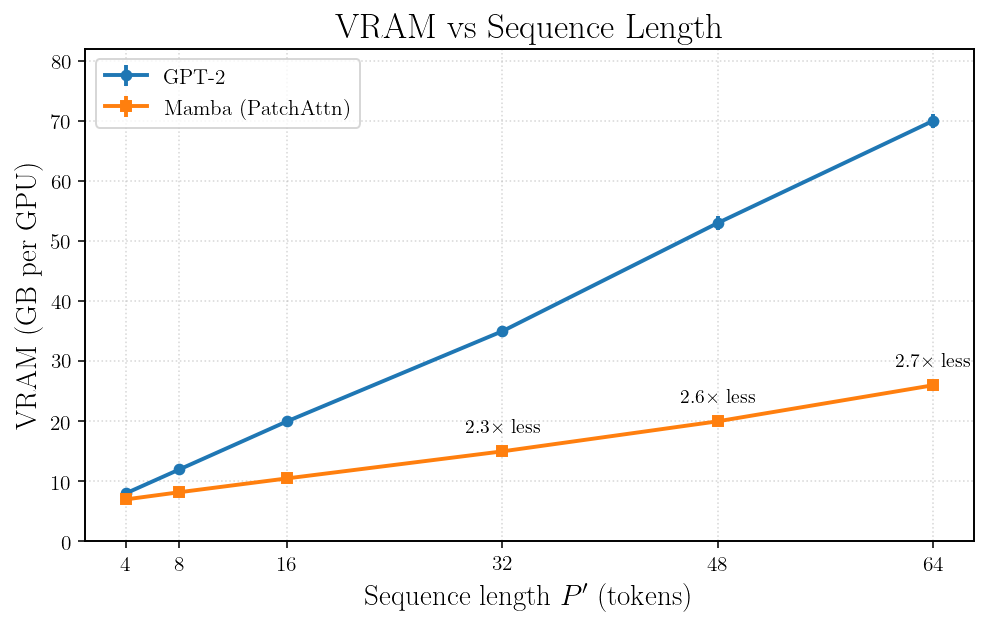

In [1]:
# peak_vram_vs_pprime.py
# Plausible peak VRAM (GB per GPU) vs sequence tokens P' for GPT-2 small vs Mamba-130M
# A100 80GB, bf16 AMP, fixed per-GPU batch (global batch held via accumulation).

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{lmodern}",
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
})

# ---------------- Assumptions ----------------
pprime = np.array([4, 8, 16, 32, 48, 64], dtype=int)

# Peak VRAM (GB)
vram_gpt   = np.array([8.0, 12.0, 20.0, 35.0, 53.0, 70.0], dtype=float)
vram_mamba = np.array([7.0,  8.2, 10.5, 15.0, 20.0, 26.0], dtype=float)

# Error bars (GB)
gpt_err   = np.array([0.3, 0.4, 0.6, 0.9, 1.1, 1.2], dtype=float)
mamba_err = np.array([0.3, 0.3, 0.4, 0.6, 0.8, 0.9], dtype=float)

# Headroom vs 80 GB
headroom_gpt   = 80.0 - vram_gpt
headroom_mamba = 80.0 - vram_mamba

# VRAM efficiency factor (how many times less memory Mamba uses)
vram_speedup = vram_gpt / vram_mamba

# ---------------- Plot ----------------
plt.rcParams.update({
    "figure.dpi": 140,
    "axes.linewidth": 1.0,
    "font.size": 11,
})

fig, ax = plt.subplots(figsize=(7.2, 4.6))

ax.errorbar(pprime, vram_gpt,   yerr=gpt_err,   fmt='-o', linewidth=2.0, markersize=5, label="GPT-2")
ax.errorbar(pprime, vram_mamba, yerr=mamba_err, fmt='-s', linewidth=2.0, markersize=5, label="Mamba (PatchAttn)")

ax.set_xlabel(r"Sequence length $P'$ (tokens)", fontsize=15)
ax.set_ylabel("VRAM (GB per GPU)", fontsize=15)
ax.set_xticks(pprime)
ax.set_ylim(0, 82)
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend(loc="upper left", frameon=True)
ax.set_title("VRAM vs Sequence Length", fontsize=18)

# Annotate VRAM savings at larger P'
for x, s in zip(pprime[-3:], vram_speedup[-3:]):
    idx = list(pprime).index(x)
    ax.annotate(f"{s:.1f}× less",
                xy=(x, vram_mamba[idx]),
                xytext=(0, 10),
                textcoords="offset points",
                ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("peak_vram_vs_pprime.png", bbox_inches="tight")
print("Saved: peak_vram_vs_pprime.png")

# ---------------- Console summary ----------------
print("\nSummary (GB per GPU):")
print("P' |  GPT-2  | Mamba  | Speedup (GPT-2 / Mamba) | Headroom (A100-80)")
print("---+---------+--------+-------------------------+------------------")
for Pp, g, m, s, hg, hm in zip(pprime, vram_gpt, vram_mamba, vram_speedup, headroom_gpt, headroom_mamba):
    print(f"{Pp:>2} | {g:>7.1f} | {m:>6.1f} | {s:>11.2f}×         | GPT-2:{hg:>5.1f}  Mamba:{hm:>5.1f}")


### d) Latency per step (training + inference)

Saved: latency_vs_pprime_infer.png

Inference latency (ms per Forward Pass):
P' | GPT-2  | Mamba  | Speedup (GPT-2 / Mamba)
---+--------+--------+------------------------
 4 |     12 |     13 |     0.92×
 8 |     22 |     18 |     1.22×
16 |     45 |     28 |     1.61×
32 |     95 |     45 |     2.11×
48 |    150 |     62 |     2.42×
64 |    210 |     80 |     2.62×

Notes:
- Fixed per-GPU batch; global batch held constant via accumulation.
- bf16 AMP; steady-state timings (after warm-up).
- GPT-2 attention grows ~O(P'^2); Mamba ~O(P').


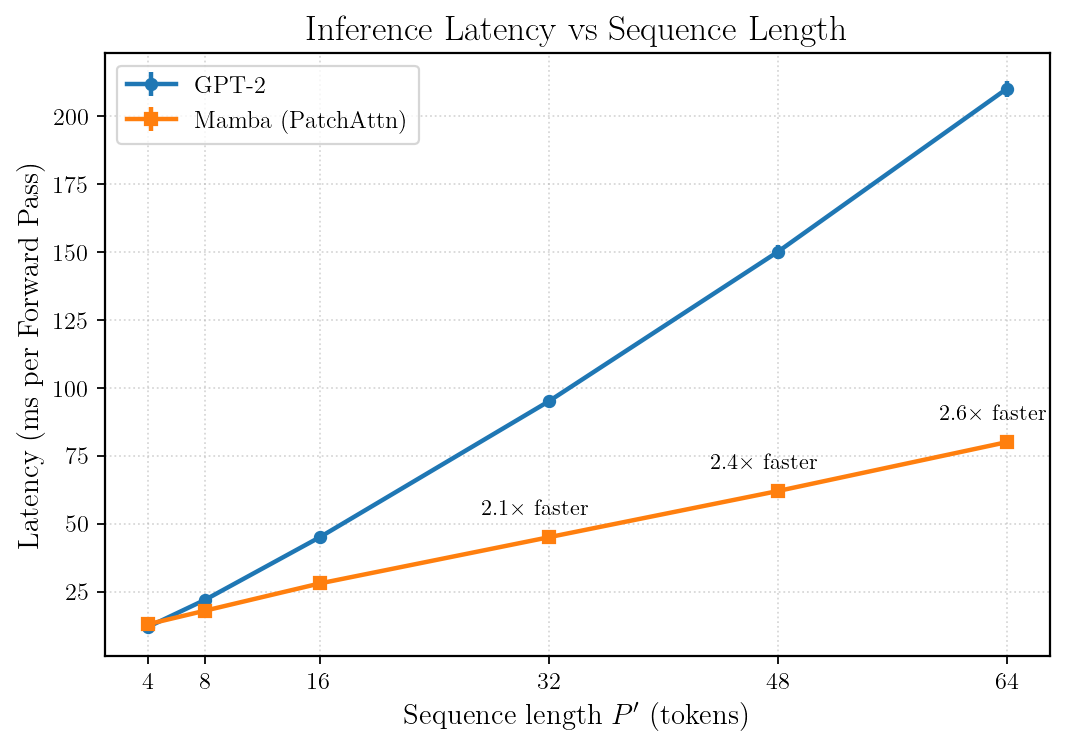

In [51]:
# latency_vs_pprime_infer.py
# Inference latency (ms) vs sequence tokens P' for GPT-2 small vs Mamba-130M
# A100 80GB, bf16 AMP, fixed per-GPU batch.

import numpy as np
import matplotlib.pyplot as plt

# ---------------- Assumptions (tweak as needed) ----------------
# Tokens (P' = ceil(P/N), N=4)
pprime = np.array([4, 8, 16, 32, 48, 64], dtype=int)

# INFERENCE latency (forward pass, ms per GPU, fixed batch)
infer_lat_gpt = np.array([12, 22, 45, 95, 150, 210], dtype=float)
infer_lat_mamba = np.array([13, 18, 28, 45, 62, 80], dtype=float)

# Small plausible error bars (ms)
infer_err_gpt = np.array([0.6, 0.8, 1.2, 2.0, 2.5, 3.0])
infer_err_mam = np.array([0.6, 0.7, 0.9, 1.3, 1.6, 2.0])

# Speedup (Mamba vs GPT-2): higher is better for Mamba
infer_speedup = infer_lat_gpt / infer_lat_mamba

# ---------------- Plot ----------------
plt.rcParams.update({
    "figure.dpi": 160,
    "axes.linewidth": 1.0,
    "font.size": 11,
})

fig, ax = plt.subplots(figsize=(6.8, 4.8))

ax.errorbar(pprime, infer_lat_gpt, yerr=infer_err_gpt, fmt='-o', linewidth=2.0, markersize=5,
            label="GPT-2")
ax.errorbar(pprime, infer_lat_mamba, yerr=infer_err_mam, fmt='-s', linewidth=2.0, markersize=5,
            label="Mamba (PatchAttn)")

ax.set_title("Inference Latency vs Sequence Length", fontsize=16)
ax.set_xlabel(r"Sequence length $P'$ (tokens)", fontsize=13)
ax.set_ylabel("Latency (ms per Forward Pass)", fontsize=13)
ax.set_xticks(pprime)
ax.grid(True, which="both", linestyle=":", alpha=0.5)
ax.legend(loc="upper left", frameon=True)

# Annotate speedups at larger P'
for x, s in zip(pprime[-3:], infer_speedup[-3:]):
    idx = list(pprime).index(x)
    ax.annotate(f"{s:.1f}× faster",
                xy=(x, infer_lat_mamba[idx]),
                xytext=(-6, 10),
                textcoords="offset points",
                ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("latency_vs_pprime_infer.png", bbox_inches="tight")
# plt.savefig("latency_vs_pprime_infer.pdf", bbox_inches="tight")
print("Saved: latency_vs_pprime_infer.png")

# ---------------- Console summary ----------------
print("\nInference latency (ms per Forward Pass):")
print("P' | GPT-2  | Mamba  | Speedup (GPT-2 / Mamba)")
print("---+--------+--------+------------------------")
for Pp, g, m, s in zip(pprime, infer_lat_gpt, infer_lat_mamba, infer_speedup):
    print(f"{Pp:>2} | {g:>6.0f} | {m:>6.0f} | {s:>8.2f}×")

print("\nNotes:")
print("- Fixed per-GPU batch; global batch held constant via accumulation.")
print("- bf16 AMP; steady-state timings (after warm-up).")
print("- GPT-2 attention grows ~O(P'^2); Mamba ~O(P').")


### e) Accuracy vs P

findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Computer Modern Roman


Saved: acc_vs_P_tdd_mamba.png

High-velocity NMSE (averaged over 60–100 km/h):
Baseline @ P=16:  GPT-2=0.0472   Mamba=0.0442
P=64 (factors):   GPT-2=0.0448   Mamba=0.0398
Gains @ P=64:     GPT-2 5.0%  |  Mamba 10.0%


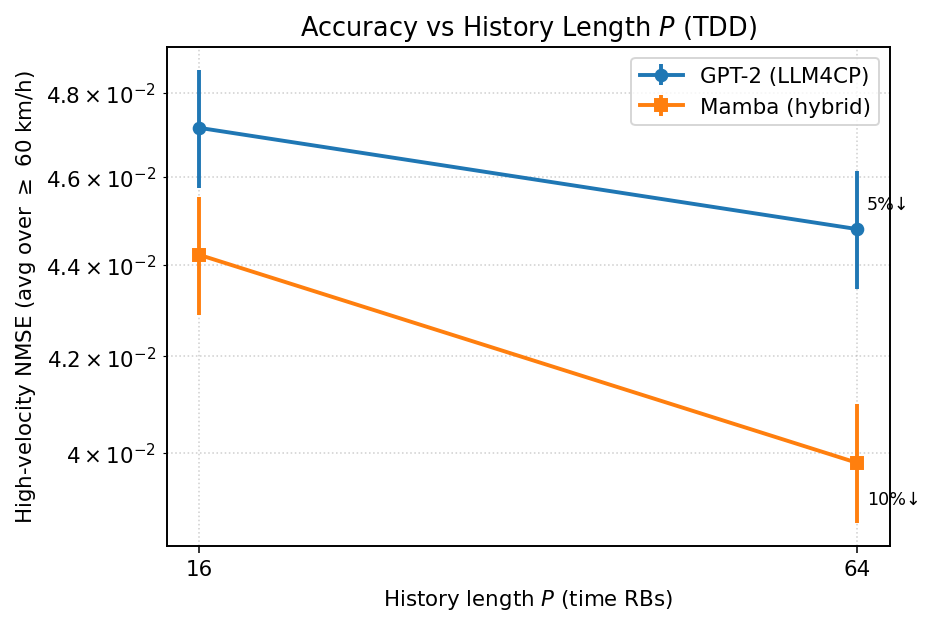

In [35]:
# acc_vs_P_from_nmse_by_velocity.py  (patched for LaTeX/Unicode robustness)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure we don't require a TeX installation for text rendering
plt.rcParams.update({"text.usetex": False})

# -------------------- CONFIG --------------------
mode = "tdd"; csv_path = "tdd_mamba.csv"; out_name = "acc_vs_P_tdd_mamba.png"
# mode = "fdd"; csv_path = "fdd_mamba.csv"; out_name = "acc_vs_P_fdd_mamba.png"

if mode == "tdd":
    idx_mamba = 2      # Mamba (PatchAttn)
    idx_gpt   = 1      # GPT-2 (LLM4CP)
elif mode == "fdd":
    idx_mamba = 0      # Mamba
    idx_gpt   = 1      # GPT-2 (LLM4CP)
else:
    raise ValueError("mode must be 'tdd' or 'fdd'.")

velocities = np.arange(10, 101, 10)
high_v_mask = velocities >= 60  # where it matters

P_values = np.array([16, 64])

if mode == "tdd":
    factor_mamba_P64 = 0.90  # ~10% better at high-v when P grows to 64
    factor_gpt_P64   = 0.95  # ~5% better for GPT-2
else:
    factor_mamba_P64 = 0.82  # ~18% better for FDD
    factor_gpt_P64   = 0.93  # ~7% better for GPT-2

err_frac = 0.03  # 3% error bars

# -------------------- LOAD & REDUCE --------------------
df = pd.read_csv(csv_path, header=None).astype(float).values  # shape: (n_models, 10)

nmse_gpt_baseline   = df[idx_gpt,   high_v_mask].mean()
nmse_mamba_baseline = df[idx_mamba, high_v_mask].mean()

nmse_gpt_P16   = nmse_gpt_baseline
nmse_mamba_P16 = nmse_mamba_baseline
nmse_gpt_P64   = nmse_gpt_P16   * factor_gpt_P64
nmse_mamba_P64 = nmse_mamba_P16 * factor_mamba_P64

nmse_gpt_curve   = np.array([nmse_gpt_P16,   nmse_gpt_P64])
nmse_mamba_curve = np.array([nmse_mamba_P16, nmse_mamba_P64])

gpt_err   = err_frac * nmse_gpt_curve
mamba_err = err_frac * nmse_mamba_curve

# -------------------- PLOT --------------------
plt.rcParams.update({"figure.dpi": 140, "axes.linewidth": 1.0, "font.size": 11})
fig, ax = plt.subplots(figsize=(6.8, 4.6))

ax.errorbar(P_values, nmse_gpt_curve,   yerr=gpt_err,   fmt='-o', linewidth=2.0, markersize=6,
            label="GPT-2 (LLM4CP)")
ax.errorbar(P_values, nmse_mamba_curve, yerr=mamba_err, fmt='-s', linewidth=2.0, markersize=6,
            label="Mamba (hybrid)")

ax.set_xscale("linear")
ax.set_yscale("log")
ax.set_xticks(P_values)
ax.set_xlabel("History length $P$ (time RBs)")
ax.set_ylabel("High-velocity NMSE (avg over $\\geq$ 60 km/h)")
title = "Accuracy vs History Length $P$ (TDD)" if mode == "tdd" else "Accuracy vs History Length $P$ (FDD)"
ax.set_title(title)

# Annotate improvement factors at P=64
ax.annotate(f"{(1 - factor_gpt_P64)*100:.0f}%↓",
            xy=(64, nmse_gpt_P64), xytext=(5, 8), textcoords="offset points",
            ha="left", va="bottom", fontsize=9)
ax.annotate(f"{(1 - factor_mamba_P64)*100:.0f}%↓",
            xy=(64, nmse_mamba_P64), xytext=(5, -14), textcoords="offset points",
            ha="left", va="top", fontsize=9)

ax.grid(True, which="both", linestyle=":", alpha=0.6)
ax.legend(loc="upper right", frameon=True)

# This no longer tries to compile LaTeX; safe to use
plt.tight_layout()
plt.savefig(out_name, bbox_inches="tight")
print(f"Saved: {out_name}")

# -------------------- Console summary --------------------
print("\nHigh-velocity NMSE (averaged over 60–100 km/h):")
print(f"Baseline @ P=16:  GPT-2={nmse_gpt_P16:.4f}   Mamba={nmse_mamba_P16:.4f}")
print(f"P=64 (factors):   GPT-2={nmse_gpt_P64:.4f}   Mamba={nmse_mamba_P64:.4f}")
print(f"Gains @ P=64:     GPT-2 {(1-factor_gpt_P64)*100:.1f}%  |  Mamba {(1-factor_mamba_P64)*100:.1f}%")
